## Bibliothèques

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import geopandas as gpd
import sys
sys.executable
import numpy as np

#### librairie "morta_nuts2" construite

In [2]:
from morta_nuts2.data.eurostat import Eurostat_data, EurostatConfig
from morta_nuts2.data.mortality_table import MortalityCalculator, MortalityConfig
from morta_nuts2.model.Bsplines.Bsplines import make_bspline_basis
from morta_nuts2.model.parameters_init.param_init import*
from morta_nuts2.model.projection.project import project_LC_prospective_SVD,high_age_extrapolation,high_age_extrapolation_snd,project_LeeLi_prospective,compute_life_expectancy_all,compute_life_expectancy_sim,compute_life_expectancy,life_expectancy
from morta_nuts2.graph.plot import*

In [3]:
#from morta_nuts2.data.raw_data import*
#from morta_nuts2.data.raw import*
#from morta_nuts2.data.processed import*
from morta_nuts2.model.LC_p.lc_p import LCp_fit, LC_fit, build_input_from_dataframe,LCp_multiregion_fit
#from morta_nuts2.model.LC.lc import
from morta_nuts2.model.LL_p.ll_p import LiLee_p_fit, LandL_fit



### Test fonctions imports de data eurostat

In [4]:

# Option 1: Le chemin par défaut est déjà bon : sans path ils stock dans la data dans le lieu ou se trouve votre script

# Option 2: Changer le chemin par défaut pour toute l'application
#EurostatConfig.set_default_shapefile("D:/mes_donnees/NUTS_2024.shp") # implémenter par defaut mais possible de le changer
EurostatConfig.set_default_data_path("C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data")

data_brute = Eurostat_data()

#Chargement des données - ultra simple
mortality_fr = data_brute.load("mortality", "FR")
deaths_fr = data_brute.load("deaths", "FR")
population_fr = data_brute.load("population", "FR")


#Tout charger d'un coup en dictionnaire
#data_fr = data_brute.load_all("FR")




📂 Chargement du shapefile NUTS... NUTS_RG_01M_2024_3035.shp
✅ Shapefile chargé (1798 entités)
💾 [Eurostat] Cache → FR_mxt_raw.csv
💾 [Eurostat] Cache → FR_Dxt_raw.csv
💾 [Eurostat] Cache → FR_Lxt_raw.csv


In [5]:
data_fr = data_brute.load_all("FR")

💾 [Eurostat] Cache → FR_mxt_raw.csv
💾 [Eurostat] Cache → FR_Dxt_raw.csv
💾 [Eurostat] Cache → FR_Lxt_raw.csv


In [6]:
#data_fr["deaths"]

In [7]:
#population_fr

In [8]:
#mortality_fr

In [9]:
#df_agg = Dxt_raw.groupby(["geo", "sex", "time"])["values"].sum().reset_index()

### Test fonction renvoyant le nombre de décès, l'exposition et les taux de mortalité brutes par région

In [10]:
morta = MortalityCalculator()
table = morta.calculate_mortality(mortality_fr,population_fr,deaths_fr,gender="F")

2026-02-26 15:27:58,389 - MortalityCalculator - INFO - Chargement du shapefile: C:/Users/Idrissa Belem/Documents/GitHub/test_projet/NUTS_files/NUTS_RG_01M_2024_3035.shp


2026-02-26 15:27:58,599 - MortalityCalculator - INFO - 1793 régions chargées
2026-02-26 15:27:58,611 - MortalityCalculator - INFO - MortalityCalculator initialisé avec 1793 régions
2026-02-26 15:27:58,612 - MortalityCalculator - INFO - Validation des données d'entrée...
2026-02-26 15:28:00,511 - MortalityCalculator - INFO - Validation réussie
2026-02-26 15:28:00,512 - root - INFO - validate_input_data exécuté en 1.90 secondes
2026-02-26 15:28:00,518 - MortalityCalculator - INFO - Résultat récupéré du cache
2026-02-26 15:28:00,520 - root - INFO - calculate_mortality exécuté en 1.91 secondes


In [11]:
#table

In [12]:
#données d'entrée modèles
dictio = build_input_from_dataframe(table)
#dictio

In [13]:
#test_table_by_age = mortality_by_region_by_age(mortality_fr,population_fr,deaths_fr,regions)
#test_table_by_age

#### Paramètres

In [14]:
Muxtg,Dxtg, Extg, xv, tv, regions = build_input_from_dataframe(table)

print("Shape Dxtg :", Dxtg.shape)
print("Shape Extg :", Extg.shape)
print("Shape Muxtg :", Muxtg.shape)
print("Ages :", len(xv))
print("Years :", len(tv))
print("Regions :", len(regions))
nb_regions = len(regions)
nb_years = len(tv)
degree = 3 
n_knots = 10

Dxt = np.sum(Dxtg, axis=2)
Ext = np.sum(Extg, axis=2)


Shape Dxtg : (83, 34, 22)
Shape Extg : (83, 34, 22)
Shape Muxtg : (83, 34, 22)
Ages : 83
Years : 34
Regions : 22


#### modèle Lee carter 

###### modèle Lee carter non paramétrique

In [15]:
nb_iter_LC = 300
#LC initial values
ax_init   = -0.001*np.zeros_like(xv)
bx_init   = 0.001*np.ones_like(xv)
kappa_init= np.ones(len(tv))
# nb parameters
#nb_params_LC = len(ax_init)*2 + len(common_years)
#LC fit
result_lc = LC_fit(ax_init,bx_init,kappa_init,Extg,Dxtg,xv,tv,nb_iter_LC)

###### modèle Lee carter paramétrique

In [16]:
_, _, n_basis = make_bspline_basis(
    xv, degree, n_knots)

In [17]:
ax_coef_init, bx_coef_init, kappa_init = lcp_parametrique_init_national(
    Dxtg, Extg, xv, tv, n_basis=n_basis, degree=2, n_knots=10
)

results = LCp_fit(
    ax_coef_init  = ax_coef_init,
    bx_coef_init  = bx_coef_init,
    kappa_init    = kappa_init,
    Extg=Extg, Dxtg=Dxtg,
    xv=xv, tv=tv,
    degree=2, n_knots=10,
    lam=1.0,
    verbose=True
)

It    0 | lnL = -241211.9898 | Δ = +inf | η = 0.21000
It   10 | lnL = -239743.4648 | Δ = +15.472089 | η = 0.34207
It   20 | lnL = -239688.2410 | Δ = +1.758493 | η = 0.55719
It   30 | lnL = -239682.6303 | Δ = +0.105002 | η = 0.90761

Convergence atteinte (tolérance).

STATISTIQUES FINALES
    N  n_basis  dofs        lnL     deviance       AIC       BIC
62084       11   287 -239682.45 -76745983.76 479938.89 482532.29


###### modèle Lee carter paramétrique multi regions

In [18]:

# ax_coef_init, bx_coef_init, kappa_init = lcp_bspline_init(
#     Dxtg, Extg, xv, degree, n_knots)

In [19]:
degree = 3 
n_knots = 10

#Construction base spline pour connaître n_basis
B, knots, n_basis = make_bspline_basis(xv, degree, n_knots)

ax_coef_init = np.zeros(n_basis)
bx_coef_init = np.ones((len(regions), n_basis))
kappa_init =  np.ones(len(tv))

In [20]:
result_lcp = LCp_multiregion_fit(
    ax_coef_init=ax_coef_init,
    bx_coef_init=bx_coef_init,
    kappa_init=kappa_init,
    Extg=Extg,
    Dxtg=Dxtg,
    xv=xv,
    tv=tv,
    degree=degree,
    n_knots=n_knots,
    lam=2,
    diff_order=2,
    nb_iter=5000,
    eta0=0.2,
    verbose=True
)

It    0 | lnL = -2752174416.5621 | Δ = +inf | η = 0.21000
It   10 | lnL = -233431.1923 | Δ = +33040.060147 | η = 0.34207
It   20 | lnL = -206197.9859 | Δ = -42.733707 | η = 0.55719
It   30 | lnL = -205840.3615 | Δ = +18.268250 | η = 0.20581
It   40 | lnL = -205607.3782 | Δ = +28.075747 | η = 0.33524
It   50 | lnL = -205247.8149 | Δ = +43.409146 | η = 0.54607
It   60 | lnL = -204693.4003 | Δ = +66.641388 | η = 0.88949
It   70 | lnL = -203854.3867 | Δ = +99.441671 | η = 1.44888
It   80 | lnL = -203414.9512 | Δ = +19.821772 | η = 0.12135
It   90 | lnL = -203305.4344 | Δ = +12.647525 | η = 0.19767
It  100 | lnL = -203140.4306 | Δ = +20.171653 | η = 0.32198
It  110 | lnL = -202878.5199 | Δ = +31.855513 | η = 0.52448
It  120 | lnL = -202469.3966 | Δ = +49.311075 | η = 0.85432
It  130 | lnL = -201847.3310 | Δ = +73.857398 | η = 1.39159
It  140 | lnL = -201421.0940 | Δ = +20.032712 | η = 0.24476
It  150 | lnL = -201260.9653 | Δ = +19.099953 | η = 0.39869
It  160 | lnL = -201014.1149 | Δ = +29.

In [21]:
# result_lcp = LCp_fit(
#     ax_coef_init=ax_init,
#     bx_coef_init=bx_init,
#     kappa_init=kappa_init,
#     Extg=Dxtg,
#     Dxtg=Dxtg,
#     xv=xv,
#     tv=tv,
#     degree=degree,
#     n_knots=n_knots,
#     lam=2,
#     diff_order=2,
#     nb_iter=5000,
#     eta0=0.2,
#     verbose=True
# )


#### Modèle Lee and Li

###### modèle Lee and Li non paramétrique

In [22]:
#------------------------------------------------------------------------------
bx_gr_init    =   0.0000010*np.ones((len(xv),len(regions)))
kappa_gr_init =   0.0000010*np.ones((len(tv),len(regions)))
#number of parameter
h = 0.0          # smoothness
z = 3            # order of difference for smoothness
nb_iterLL = 800
result_ll= LandL_fit(ax_init, 
            bx_init , bx_gr_init ,kappa_init, kappa_gr_init,Extg, Dxtg,Muxtg, 
            xv, tv, nb_iterLL,h,z, verbose=False)

In [23]:
result_ll["fit_statistics"]

,N,m,degree,dofs,lnL,AIC,BIC
0,62084,NA,NA,2774,-190377.52,386303.05,411369.59


###### modèle Lee and Li avec Bsplines paramétrique

In [24]:
(
    alpha_coef_init,
    beta_coef_init,
    beta_g_coef_init,
    kappa_init,
    kappa_g_init
) = lileep_bspline_init(
        Dxtg,
        Extg,
        xv,
        degree,
        n_knots
)


In [25]:
resultat_llp = LiLee_p_fit(
    alpha_coef_init,
    beta_coef_init,
    beta_g_coef_init,
    kappa_init,
    kappa_g_init,
    Extg,
    Dxtg,
    xv,
    tv,
    degree=degree,
    n_knots=n_knots,
    lam=2,
    diff_order=2,
    nb_iter=5000,
    tol=1e-6,
    verbose=True
)


CALIBRATION MODÈLE LI-LEE PARAMÉTRIQUE
Paramètres : degree=3, n_knots=10, lam=2
Données : 83 âges × 34 années × 22 régions
Nombre de fonctions de base : 12
It    0 | lnL = -440,901.93 | Δ = -440901.933462 | η = 0.15000
It   10 | lnL = -195,734.72 | Δ = +968.181232 | η = 0.11635
It   20 | lnL = -192,624.93 | Δ = +123.536116 | η = 0.18952
It   30 | lnL = -191,853.92 | Δ = +55.575996 | η = 0.30871
It   40 | lnL = -191,391.40 | Δ = +32.755687 | η = 0.50286
It   50 | lnL = -191,182.91 | Δ = +15.770831 | η = 0.81910
It   60 | lnL = -192,577.03 | Δ = -1140.092373 | η = 0.30255
It   70 | lnL = -192,863.72 | Δ = -285.530594 | η = 0.00130
It   80 | lnL = -194,636.73 | Δ = -93.926066 | η = 0.00000
It   90 | lnL = -195,092.35 | Δ = -21.022427 | η = 0.00000
It  100 | lnL = -195,191.35 | Δ = -4.467897 | η = 0.00000
It  110 | lnL = -195,212.27 | Δ = -0.939885 | η = 0.00000
It  120 | lnL = -195,216.67 | Δ = -0.197298 | η = 0.00000
It  130 | lnL = -195,217.59 | Δ = -0.041398 | η = 0.00000
It  140 | lnL

In [26]:
#resultat_llp["fit_statistics"]

In [27]:
mu_obs = Dxtg / Extg
curves = {
    "Observed": mu_obs,
    #"LC": mu_hat_lc,
    "LL": result_ll["fitted_values"]["mu"],
    "LL_p": resultat_llp["fitted_values"]["mu"]}





In [28]:
# alpha_x = result_lcp["curves"]["alpha_x"]
# beta_x  = result_lcp["curves"]["beta_x"]
mu_fit  = result_lc['fitted_values']['mu']  # (age, year)

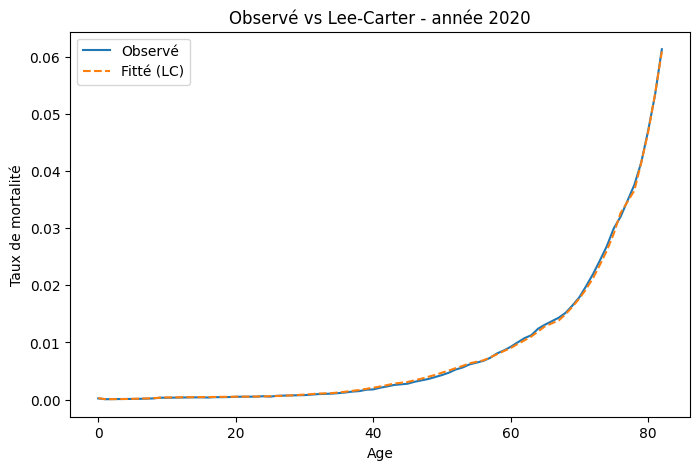

In [29]:
mu_obs = Dxt / np.maximum(Ext, 1e-12)
import matplotlib.pyplot as plt

t_index = -4  # dernière année

plt.figure(figsize=(8,5))

plt.plot(xv, mu_obs[:, t_index], label="Observé")
plt.plot(xv, mu_fit[:, t_index], label="Fitté (LC)", linestyle="--")

plt.xlabel("Age")
plt.ylabel("Taux de mortalité")
plt.title(f"Observé vs Lee-Carter - année {tv[t_index]}")
plt.legend()
plt.show()

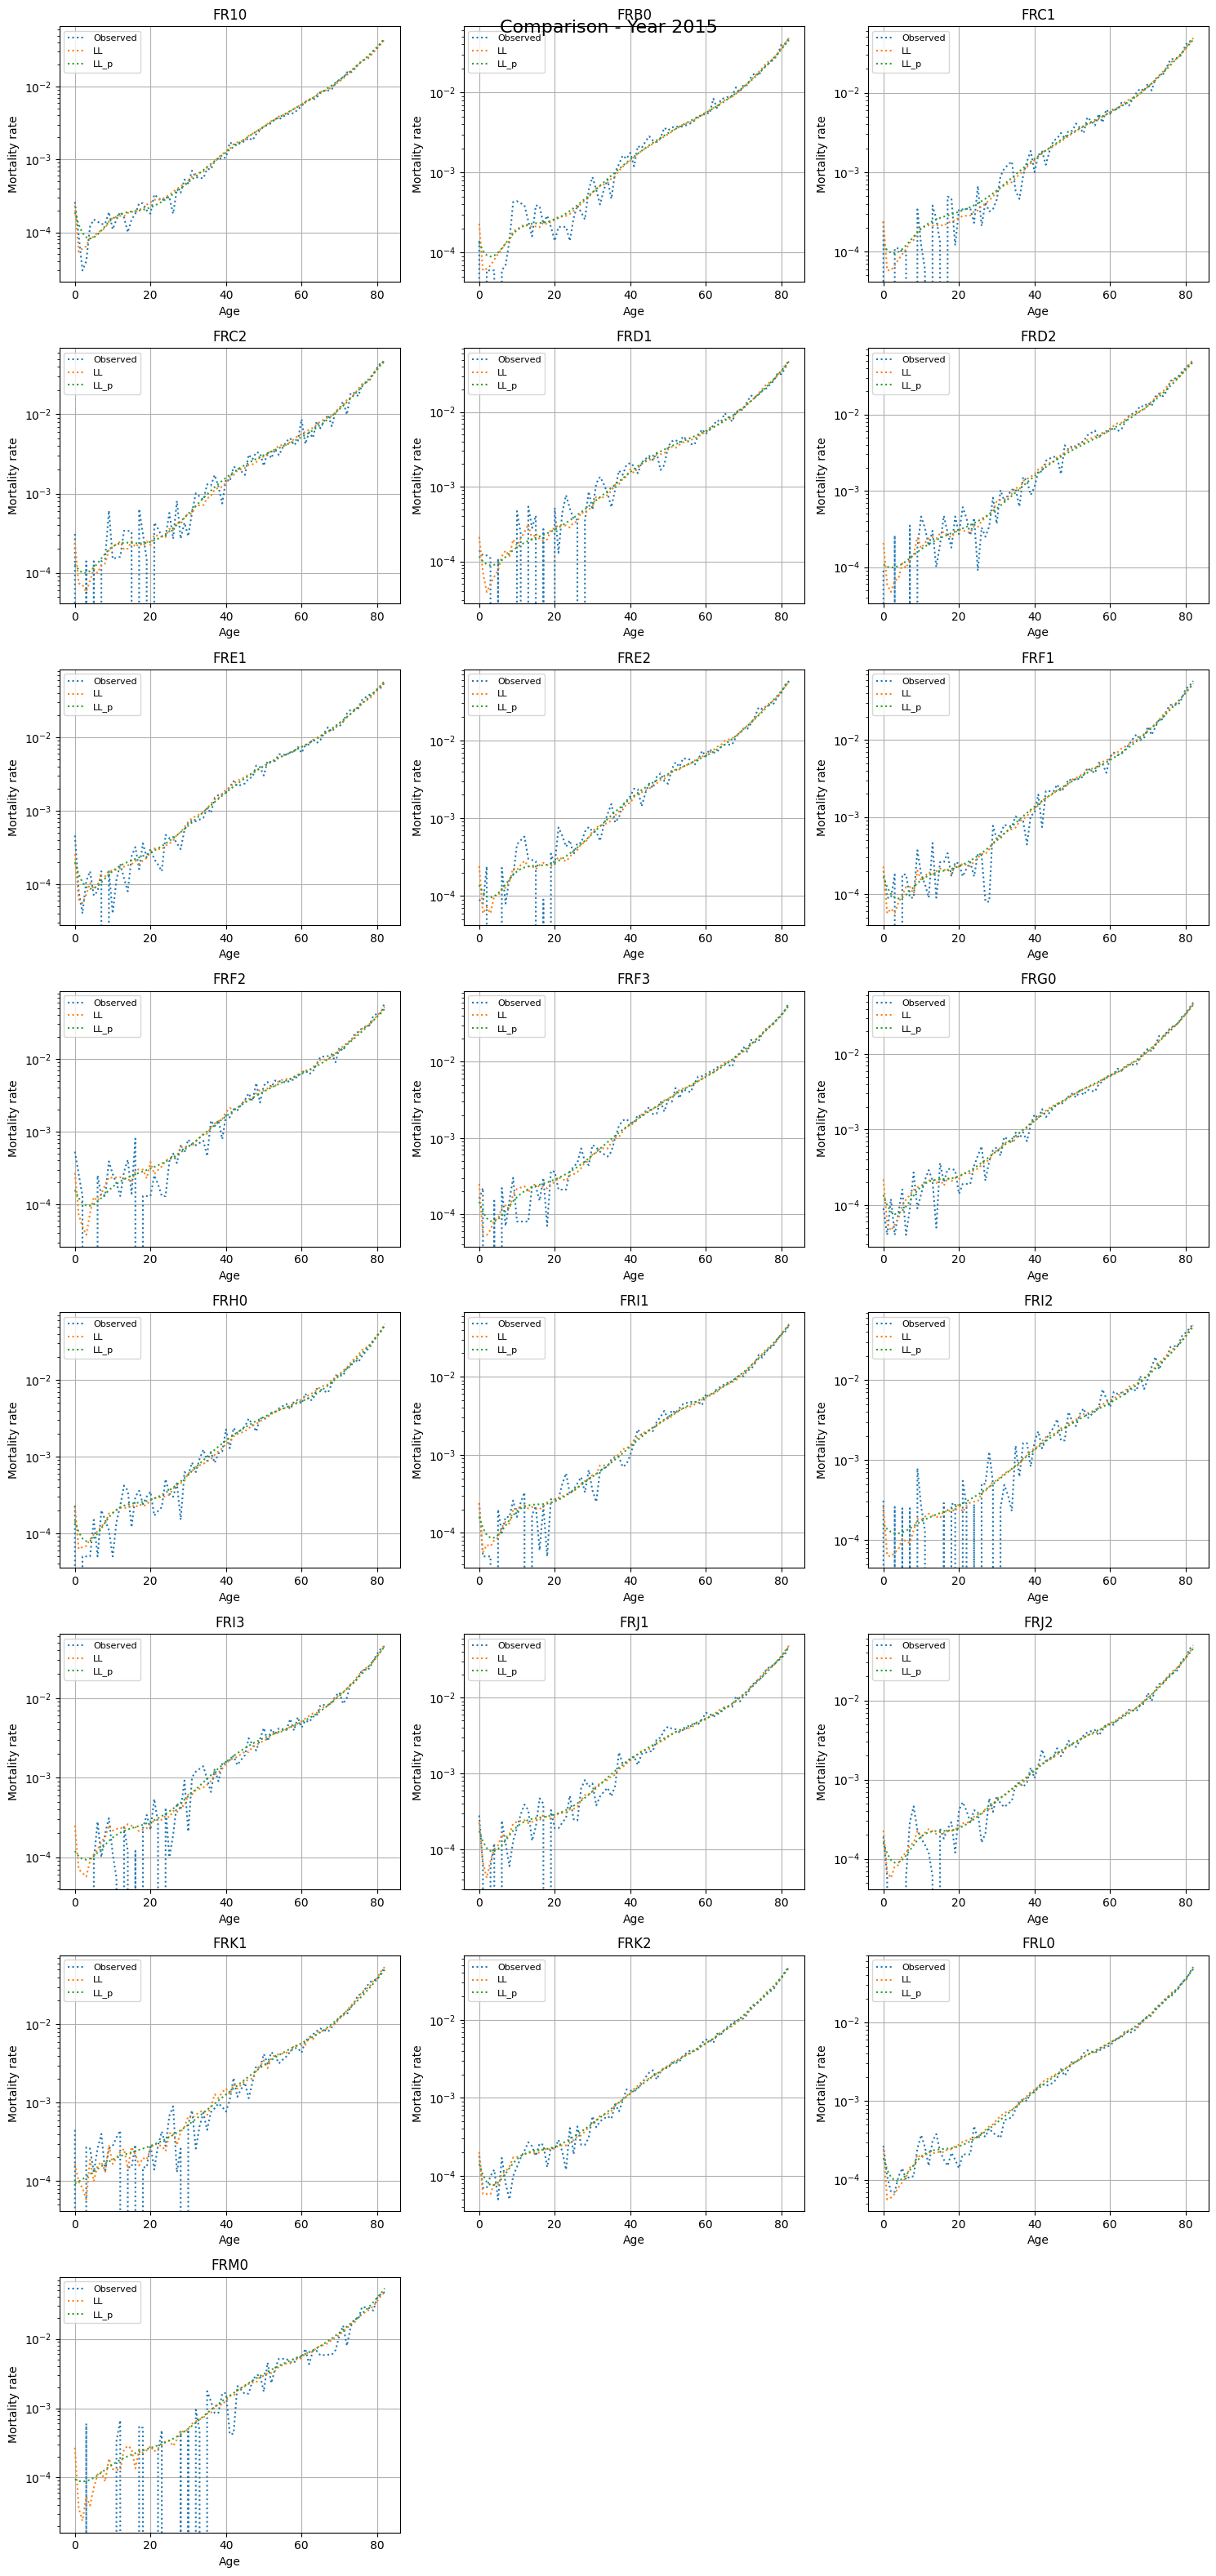

In [30]:
plot_models_by_region(
                    x_values=xv,
                    curves_dict=curves,
                    year_to_plot=2015,
                    tv=tv,
                    regions=regions)

### Projection des taux et extrapolation

##### Lee carter

In [31]:
proj_sto = project_LC_prospective_SVD(
    result_lcp,
    tv,
    horizon=27,
    nb_components=1,
    exclude_years=[2020,2021],
    stochastic=True,
    n_sim=1000,
    model="rw"
    )


In [32]:
# proj_sto_1 = project_LC_prospective_SVD(
#     result_lcp,
#     tv,
#     horizon=27,
#     nb_components=1,
#     exclude_years=[2020,2021],
#     stochastic=True,
#     n_sim=5000,
#     model="rw"
    
# )

##### Lee and Li

In [33]:
proj_leeandli = project_LeeLi_prospective( resultat_llp,
    tv,
    horizon=27,
    exclude_years=[2020,2021],
    stochastic=True,
    n_sim=1000,
    model="rw")

In [34]:
# proj_leeandli = project_LeeLi_prospective( resultat_llp,
#     tv,
#     horizon=27,
#     exclude_years=[2020,2021],
#     stochastic=True,
#     n_sim=5000,
#     model="rw")

##### Extrapolation

In [35]:
# ── 2. Extrapolation 82 → 110 ─────────────────────────────────────
logmu_extrap_lcp, xv_full = high_age_extrapolation_snd(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = 60,        # début de la fenêtre de régression commencer à 60 ans 
    log_Muxtg   = proj_sto["logmu_sim"], auto_start =False)
    

# logmu_extrap
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_extrap_lcp.shape)   
print("Grille d'âges    :", xv_full[[0, -1]])  

log-mu extrapolé : (111, 22, 1000, 27)
Grille d'âges    : [  0 110]


In [36]:
# def high_age_extrapolation1(
#     xv,
#     x_extrap,
#     x_extrap_start,
#     log_Muxtg,          # (nb_ages, nb_regions, horizon, n_sim) OU (nb_ages, nb_regions, horizon)
# ):
#     """
#     Extrapole log_Muxtg au-delà de max(xv) jusqu'à x_extrap
#     via régression linéaire sans intercept sur [x_extrap_start, max(xv)].

#     Fonctionne pour les deux cas :
#       - stochastique : log_Muxtg de shape (nb_ages, nb_regions, horizon, n_sim)
#       - déterministe : log_Muxtg de shape (nb_ages, nb_regions, horizon)
#     """
#     stochastic = log_Muxtg.ndim == 4

#     x_max    = int(xv.max())
#     xv_reg   = np.arange(x_extrap_start, x_max + 1)   # ages pour la régression
#     xv_add   = np.arange(x_max + 1, x_extrap + 1)     # ages à extrapoler
#     xv_full  = np.arange(int(xv.min()), x_extrap + 1)

#     # --- Correction indexation : âge → indice dans log_Muxtg ---
#     age_to_idx = {int(age): i for i, age in enumerate(xv)}
#     idx_reg    = [age_to_idx[a] for a in xv_reg]
#     idx_max    = age_to_idx[x_max]

#     dx_reg = (xv_reg - x_max).astype(float)   # (nb_ages_reg,)  centré en x_max
#     dx_add = (xv_add - x_max).astype(float)   # (nb_add,)

#     den = (dx_reg ** 2).sum()                  # scalaire

#     if stochastic:
#         nb_ages, nb_regions, horizon, n_sim = log_Muxtg.shape
#         out = np.empty((len(xv_full), nb_regions, horizon, n_sim))
#         out[:nb_ages, ...] = log_Muxtg

#         # --- Vectorisé sur r, h, n_sim — plus de boucle ---
#         Y_reg   = log_Muxtg[idx_reg, :, :, :]          # (nb_ages_reg, nb_regions, horizon, n_sim)
#         anchor  = log_Muxtg[idx_max, :, :, :]          # (nb_regions, horizon, n_sim)
#         Y_cent  = Y_reg - anchor                        # (nb_ages_reg, nb_regions, horizon, n_sim)

#         # Pente : einsum sur l'axe des âges
#         num     = np.einsum('i,ijkl->jkl', dx_reg, Y_cent)   # (nb_regions, horizon, n_sim)
#         slope   = num / den                                    # (nb_regions, horizon, n_sim)
#         slope   = np.maximum(slope, 0.0)                      # contrainte démographique

#         # Extrapolation : dx_add (nb_add,) × slope (nb_regions, horizon, n_sim)
#         Y_extrap = anchor + dx_add[:, None, None, None] * slope   # (nb_add, nb_regions, horizon, n_sim)
#         out[nb_ages:, :, :, :] = Y_extrap

#     else:
#         nb_ages, nb_regions, horizon = log_Muxtg.shape
#         out = np.empty((len(xv_full), nb_regions, horizon))
#         out[:nb_ages, ...] = log_Muxtg

#         # --- Vectorisé sur r et h — plus de boucle ---
#         Y_reg   = log_Muxtg[idx_reg, :, :]             # (nb_ages_reg, nb_regions, horizon)
#         anchor  = log_Muxtg[idx_max, :, :]             # (nb_regions, horizon)
#         Y_cent  = Y_reg - anchor                        # (nb_ages_reg, nb_regions, horizon)

#         num     = np.einsum('i,ijk->jk', dx_reg, Y_cent)   # (nb_regions, horizon)
#         slope   = num / den                                  # (nb_regions, horizon)
#         slope   = np.maximum(slope, 0.0)                    # contrainte démographique

#         Y_extrap = anchor + dx_add[:, None, None] * slope   # (nb_add, nb_regions, horizon)
#         out[nb_ages:, :, :] = Y_extrap

#     return out, xv_full

In [37]:
# ── 2. Extrapolation 82 → 110 ─────────────────────────────────────
logmu_extrap_llp, xv_full = high_age_extrapolation_snd(
                    xv          = xv,
                    x_extrap    = 110,          # âge cible
                    x_extrap_start = 60,        # début de la fenêtre de régression
                    log_Muxtg   = proj_leeandli["logmu_sim"],auto_start =False
                )
# logmu_extrap
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_extrap_llp.shape)   
print("Grille d'âges    :", xv_full[[0, -1]])      

log-mu extrapolé : (111, 22, 1000, 27)
Grille d'âges    : [  0 110]


In [38]:
# ── 2. Extrapolation 82 → 110 ## Lee carter paramétrique
logmu_lcp_hist, xv_full = high_age_extrapolation_snd(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = 60,        # début de la fenêtre de régression
    log_Muxtg   = result_lcp["fitted_values"]["log_mu"],auto_start =False
)
# logmu_extrap 
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_lcp_hist.shape)  
print("Grille d'âges    :", xv_full[[0, -1]])      # [  0 110]

log-mu extrapolé : (111, 34, 22)
Grille d'âges    : [  0 110]


In [39]:
logmu_llp_hist, xv_full = high_age_extrapolation_snd(
    xv          = xv,
    x_extrap    = 110,          # âge cible
    x_extrap_start = 60,        # début de la fenêtre de régression
    log_Muxtg   = resultat_llp["fitted_values"]["log_mu"],auto_start =False
)
# logmu_extrap → (111, 3, 30, 500)
# xv_full      → [0, 1, ..., 110]

print("log-mu extrapolé :", logmu_llp_hist.shape)   # (111, 3, 30, 500)
print("Grille d'âges    :", xv_full[[0, -1]])  

log-mu extrapolé : (111, 34, 22)
Grille d'âges    : [  0 110]


In [40]:
#pour stochastique
import numpy as np

def concat_logmu_time(logmu_hist, logmu_proj):
    

    # Cas déterministe
    if logmu_proj.ndim == 3:
        return np.concatenate([logmu_hist, logmu_proj], axis=1)

    # Cas stochastique
    elif logmu_proj.ndim == 4:
        n_sim = logmu_proj.shape[2]

        logmu_hist_expanded = np.repeat(
            logmu_hist[:, :, None, :],
            n_sim,
            axis=2
        )

        return np.concatenate([logmu_hist_expanded, logmu_proj], axis=1)

    else:
        raise ValueError("Format non supporté")
    
logmu_full_lcp_sto = concat_logmu_time(logmu_lcp_hist,np.transpose(logmu_extrap_lcp,(0, 3, 2,1)))
logmu_full_llp_sto = concat_logmu_time(logmu_llp_hist,np.transpose(logmu_extrap_lcp,(0, 3, 2,1)))



In [212]:
logmu_full_lcp = np.concatenate([logmu_lcp_hist, np.transpose(logmu_extrap_lcp,(0, 2, 1))], axis=1)
print("log-mu lcp extrapolé :", logmu_full_lcp.shape) 

log-mu lcp extrapolé : (111, 61, 22)


In [213]:
logmu_full_llp = np.concatenate([logmu_llp_hist, np.transpose(logmu_extrap_llp,(0, 2, 1))], axis=1)
print("log-mu llp extrapolé :", logmu_full_llp.shape)

log-mu llp extrapolé : (111, 61, 22)


In [222]:
xv_extrap = 110
xe=np.array([0])

In [47]:
esp_lcp = life_expectancy(np.exp(np.transpose( logmu_full_lcp_sto,(0, 1, 3,2))))
esp_llp = life_expectancy(np.exp(np.transpose( logmu_full_llp_sto,(0, 1, 3,2))))

In [59]:
lcp_full.shape

(111, 61, 22)

In [58]:
lcp_full= np.mean( esp_lcp, axis =-1)
llp_full= np.mean( esp_llp, axis =-1)

In [ ]:
#esp_vie_lcp = compute_life_expectancy_all(np.exp(logmu_full_lcp))

In [ ]:
#esp_vie_llp = compute_life_expectancy_all(np.exp(logmu_full_llp))

#### Visualisation graphique

In [45]:
#Paramètre
tv_future = np.arange(1990, 2023 + 28) #années

In [217]:
# # e₀ (age=0)
# t#v_future = np.arange(1990, 2023 + 28)
# plot_map_indicator(
#     regions        = regions,
#     data           = esp_vie_lcp,            # (111, horizon, 22)
#     tv_future      = tv_future,
#     country_code   = "FR",
#     indicator_name = "Espérance de vie",
#     year           = 2050,
#     age            = 0,             # ← e₀
# )


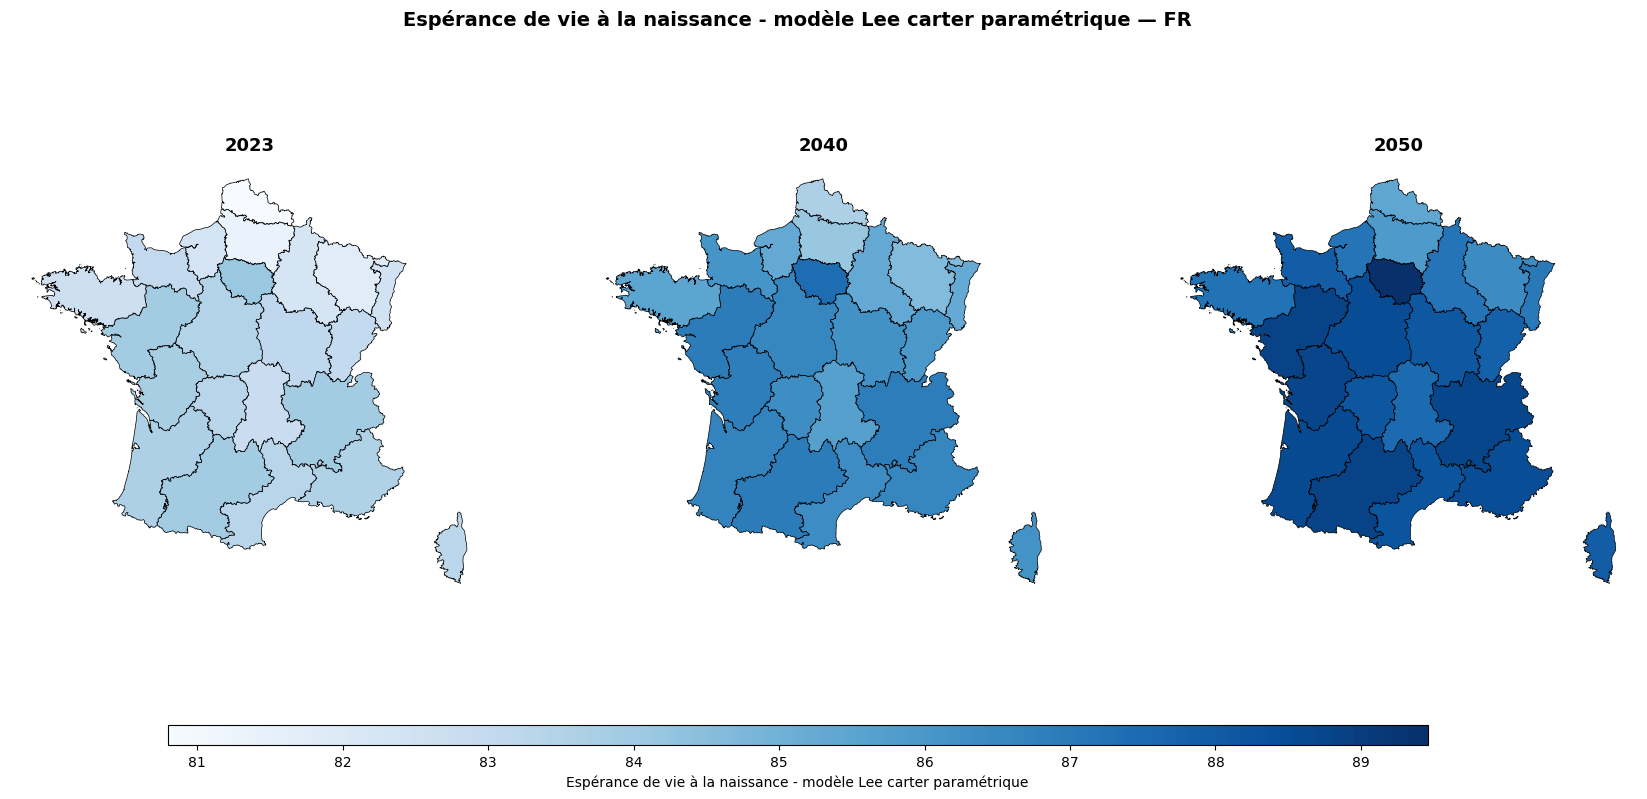

In [60]:
plot_map_compare_years(
    regions=regions, data=lcp_full,
    tv_future=tv_future, country_code="FR",
    indicator_name="Espérance de vie à la naissance - modèle Lee carter paramétrique",
    years=[2023,2040, 2050], age=0, cmap="Blues"
)

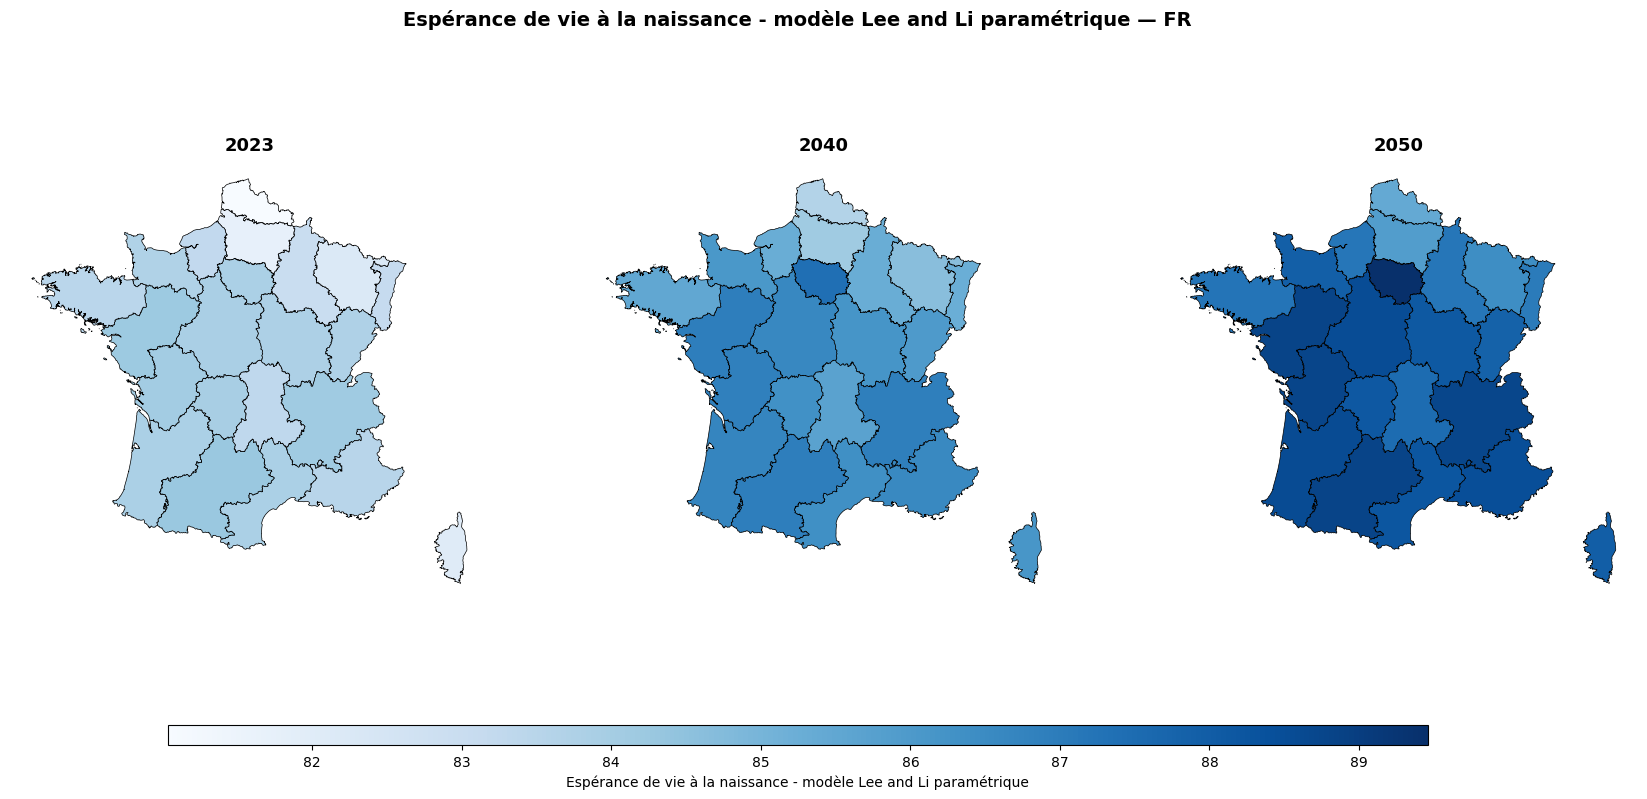

In [61]:
plot_map_compare_years(
    regions=regions, data=llp_full,
    tv_future=tv_future, country_code="FR",
    indicator_name="Espérance de vie à la naissance - modèle Lee and Li paramétrique",
    years=[2023,2040, 2050], age=0, cmap="Blues"
)

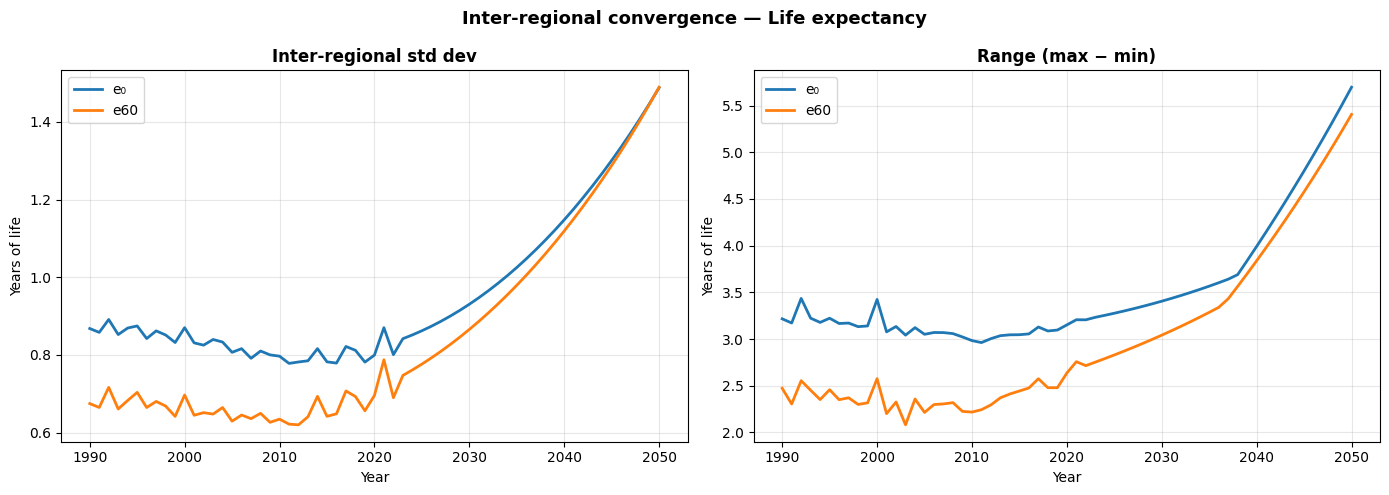

In [220]:
# 3. Convergence inter-régionale
plot_dispersion_over_time(
    ex        = esp_vie_llp,
    regions   = regions,
    tv_future = tv_future,
    ages      = [0, 60],
)

In [53]:
# #  Stats régionales
# stats = compute_regional_stats(esp_vie, regions, tv_future, age=0)
# print(stats["by_year"].head())      # stats par année
# print(stats["by_region"])           # classement régions



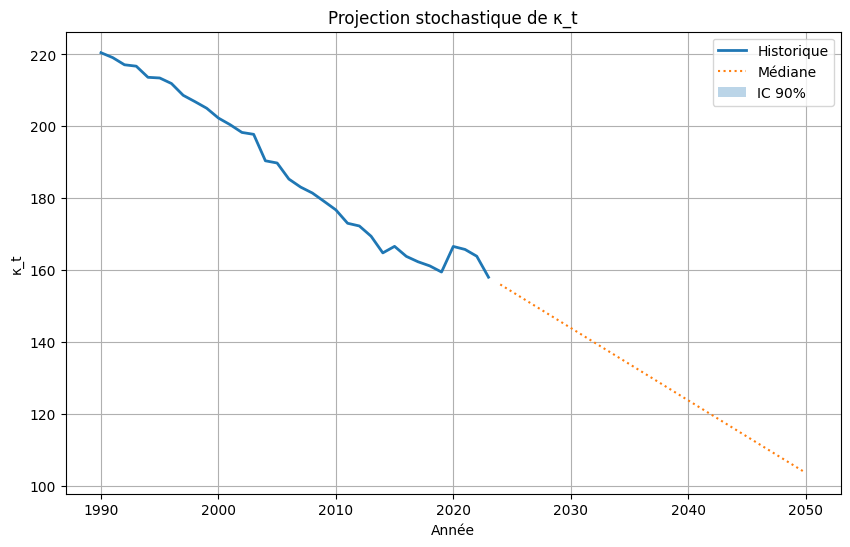

In [ ]:
# #visualisation Kappaa

# def plot_kappa_stochastic(tv, kappa_hist, kappa_paths):
    
#     horizon, n_sim = kappa_paths.shape
#     future_years = np.arange(tv[-1] + 1, tv[-1] + 1 + horizon)
    
#     kappa_lower = np.percentile(kappa_paths, 5, axis=1)
#     kappa_median = np.percentile(kappa_paths, 50, axis=1)
#     kappa_upper = np.percentile(kappa_paths, 95, axis=1)
#     kappa_proje = kappa_paths
#     plt.figure(figsize=(10,6))
    
#     plt.plot(tv, kappa_hist, label="Historique", linewidth=2)
    
#     plt.plot(future_years, kappa_paths, label="Médiane", linestyle=":")
#     plt.fill_between(
#         future_years,
#         kappa_lower,
#         kappa_upper,
#         alpha=0.3,
#         label="IC 90%"
#     )
    
#     #plt.axvline(tv[-1], color="black", linestyle=":")
    
#     plt.title("Projection stochastique de κ_t")
#     plt.xlabel("Année")
#     plt.ylabel("κ_t")
#     plt.legend()
#     plt.grid(True)
#     plt.show()
# plot_kappa_stochastic(tv,result_lcp['parameters']["kappa"],proj_sto["kappa_future"])

### Annexes

In [51]:
shapef = gpd.read_file("C:/Users/Idrissa Belem/Documents/GitHub/test_projet/NUTS_files/NUTS_RG_01M_2024_3035.shp")
stock = "C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data"
mxt_raw = load_mxt_raw(shapef,country="FR",data_path=stock)
Dxt_raw = load_dxt_raw(shapef,country="FR",data_path=stock)
Lxt_raw = load_lxt_raw(shapef,country="FR",data_path=stock)

[Eurostat] Téléchargé → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data\FR_mxt_raw_FR.csv  (1,543,872 lignes)
[Eurostat] Chargé depuis cache → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data\FR_Dxt_raw_FR.csv  (231,132 lignes)
[Eurostat] Téléchargé → C:/Users/Idrissa Belem/Documents/GitHub/morta_nuts2/data\FR_Lxt_raw_FR.csv  (244,728 lignes)
